# Exercise 1D

## 0. Setup

### Imports

In [1]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import math

### Load Images

In [2]:
query_img = cv2.imread("images/ragu1.jpeg")
query_img = cv2.cvtColor(query_img, cv2.COLOR_BGR2HSV)
target_img = cv2.imread("images/ragu2.jpg")
target_img = cv2.cvtColor(target_img, cv2.COLOR_BGR2HSV)
img3 = cv2.imread("images/decaval.jpg")
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2HSV)
img4 = cv2.imread("images/banhmi.jpg")
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2HSV)

In [3]:
img_dict = {
    "query_img":query_img,
    "target_img":target_img,
    "img3":img3,
    "img4":img4
}

(np.float64(-0.5), np.float64(1399.5), np.float64(932.5), np.float64(-0.5))

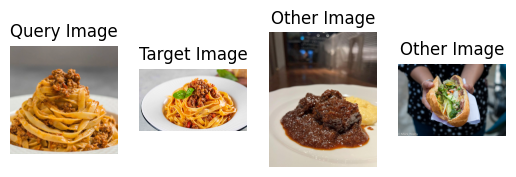

In [4]:
plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(query_img, cv2.COLOR_HSV2RGB))
plt.title("Query Image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(cv2.cvtColor(target_img, cv2.COLOR_HSV2RGB))
plt.title("Target Image")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(cv2.cvtColor(img3, cv2.COLOR_HSV2RGB))
plt.title("Other Image")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(cv2.cvtColor(img4, cv2.COLOR_HSV2RGB))
plt.title("Other Image")
plt.axis("off")


## 1. Color Histogram

### Quantization
Set the bin for each channel, with minimum as 1. To ignore variation in a channel, set it to 1

In [5]:
H_BIN = 8
S_BIN = 8
V_BIN = 1

# Prevent 0
H_BIN = H_BIN if H_BIN != 0 else 1
S_BIN = S_BIN if S_BIN != 0 else 1
V_BIN = V_BIN if V_BIN != 0 else 1

In [6]:
# Takes in a img with hsv matrix, and the bin number for hsv values
# returns a flattened vector of the hsv with each element representing the bin index
def quantize(img,h_bin=H_BIN,s_bin=S_BIN,v_bin=V_BIN):
    h_val = img[:, :, 0].astype(np.int32) #need to be set to int32 because multiplication 
    s_val = img[:, :, 1].astype(np.int32)
    v_val = img[:, :, 2].astype(np.int32)

    # Qunatize and assign the bin value for each value
    h_index = (h_val * h_bin // 180).astype(np.int32) # H is supposed to be 360 because its an angle but cv store as uint8 so only up to 256, thats why its 180
    s_index = (s_val * s_bin // 256).astype(np.int32)
    v_index = (v_val * v_bin // 256).astype(np.int32)

    # Get the bin index for each pixel
    index = (h_index * (s_bin * v_bin)) + (s_index * v_bin) + v_index

    # Flatten into 1D Vector
    pixel_bin_indices = index.flatten()

    return(pixel_bin_indices)

In [7]:
pixel_bin_indices = quantize(query_img,H_BIN,S_BIN,V_BIN) # Each element is pixel represented with its color as a bin index after quantization

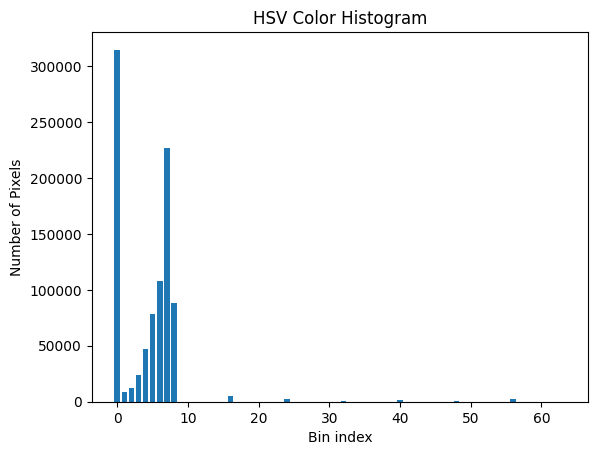

In [8]:
bincount = np.bincount(pixel_bin_indices, minlength=H_BIN * S_BIN * V_BIN) # count of the pixel in each bins
bincount = bincount.astype(np.float32)

plt.figure()
plt.bar(range(len(bincount)), bincount)
plt.title("HSV Color Histogram")
plt.xlabel("Bin index")
plt.ylabel("Number of Pixels")
plt.show()

### Convert to probability

In [9]:
def get_color_prob_distribution(pixel_bin_indices,num_bins = H_BIN * S_BIN * V_BIN):
    bincount = np.bincount(pixel_bin_indices, minlength=num_bins) # count of the pixel in each bins
    bincount = bincount.astype(np.float32)
    color_prob_distribution = bincount / bincount.sum() # convert to probability since every img have different number of pixels

    return color_prob_distribution

In [10]:
color_prob_distribution = get_color_prob_distribution(pixel_bin_indices)

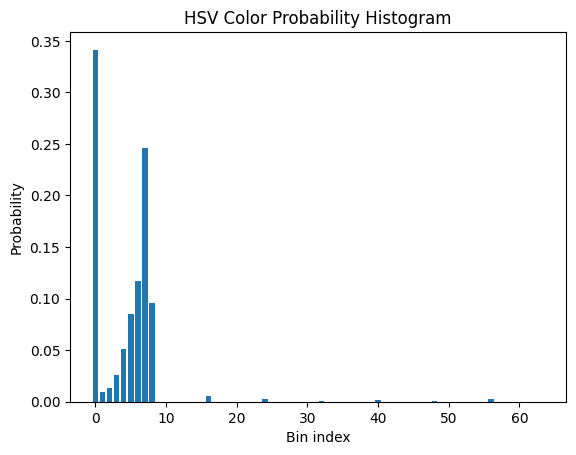

In [11]:
plt.figure()
plt.bar(range(len(color_prob_distribution)), color_prob_distribution)
plt.title("HSV Color Probability Histogram")
plt.xlabel("Bin index")
plt.ylabel("Probability")
plt.show()

## 2. Lp Norm and Quadratic Distance
Comparison between using Lp Norm and Quadratic Distance for dissimilarity calculation

**Will not use weighted Lp Norm since it's hard to assign weights*

### Lp Norm

In [12]:
# p=1 for manhattan distance, p=2 for euclidean distance
# euclidean distance by default
def compute_lp_norm(vector_a,vector_b,p=2):
    distance = 0 
    for i in range(0,len(vector_a)):
        distance += (abs(vector_a[i]-vector_b[i]))**(p)

    distance = distance**(1/p)
    return distance

#### Euclidean Lp Norms

In [13]:
query_img_color_prob = get_color_prob_distribution(quantize(query_img))
for image_name,image_hsv in img_dict.items():
    reference_img_color_prob = get_color_prob_distribution(quantize(image_hsv))
    lp_norm_distance = compute_lp_norm(query_img_color_prob,reference_img_color_prob)
    print(f"{image_name}: {lp_norm_distance}")

query_img: 0.0
target_img: 0.1737612783908844
img3: 0.2858429551124573
img4: 0.4775160253047943


#### Manhattan Lp Norms

In [14]:
query_img_color_prob = get_color_prob_distribution(quantize(query_img))
for image_name,image_hsv in img_dict.items():
    reference_img_color_prob = get_color_prob_distribution(quantize(image_hsv))
    lp_norm_distance = compute_lp_norm(query_img_color_prob,reference_img_color_prob,p=1)
    print(f"{image_name}: {lp_norm_distance}")

query_img: 0.0
target_img: 0.48366159200668335
img3: 0.7764487266540527
img4: 1.666319727897644


### Quadratic Distance

In [15]:
def compute_quadratic_distance(vector_a,vector_b,A):
    scalar_diff = (vector_a-vector_b)
    result = scalar_diff.T @ A @ scalar_diff

    return result

query_img_color_prob = get_color_prob_distribution(quantize(query_img))
target_img_color_prob = get_color_prob_distribution(quantize(target_img))
A = np.eye(len(query_img_color_prob))
print(compute_quadratic_distance(query_img_color_prob,target_img_color_prob,A))

0.030192986629442337


In [16]:
query_img_color_prob = get_color_prob_distribution(quantize(query_img))
A = np.eye(len(query_img_color_prob))
for image_name,image_hsv in img_dict.items():
    reference_img_color_prob = get_color_prob_distribution(quantize(image_hsv))
    quadratic_distance = compute_quadratic_distance(query_img_color_prob,reference_img_color_prob,A)
    print(f"{image_name}: {quadratic_distance}")

query_img: 0.0
target_img: 0.030192986629442337
img3: 0.08170619683975625
img4: 0.22802148067995695


### Quadratic Distance (with Gaussian)
This gives weights to the relationship between bins, bins that are closer to one another are stronger while bins that are further are less strong, dones by applying gaussian

In [17]:
query_img_color_prob = get_color_prob_distribution(quantize(query_img))
n = len(query_img_color_prob)

sigma = 2
A = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dist = min(abs(i - j), n - abs(i - j)) # Hue is a circle so it should wrap around
        A[i, j] = np.exp(-(dist**2) / (2 * sigma**2))

for image_name,image_hsv in img_dict.items():
    reference_img_color_prob = get_color_prob_distribution(quantize(image_hsv))
    quadratic_distance = compute_quadratic_distance(query_img_color_prob,reference_img_color_prob,A)
    print(f"{image_name}: {quadratic_distance}")

query_img: 0.0
target_img: 0.05932439639223601
img3: 0.145104977149623
img4: 0.3870142545730852
